#  <font color='#FFE15D'><b>💎 Introduction to Reinforcement Learning </b></font><font color='#FF0B55'></font>

## 🔴 **Import & Setup**

In [1]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical

import numpy as np
import matplotlib.pyplot as plt
import os
import random

In [2]:
ENV_CONFIG = {

    "CartPole-v1": {
        "video_every": 20,
        "video_folder": "./cartpole"
    },

    "LunarLander-v3": {
        "video_every": 100,
        "video_folder": "./lunarlander"
    }

}

## 🔴 **Policy Networks**

In [3]:
# Define the Policy Networks 
class PolicyNet(nn.Module):
    def __init__(self, state_dim, action_dim, env_name="CartPole-v1"):
        super().__init__()

        if env_name == "CartPole-v1":
            self.fc = nn.Sequential(
                nn.Linear(state_dim, 64),
                nn.ReLU(),
                nn.Linear(64, action_dim)
            )

        elif env_name == "LunarLander-v3":
            self.fc = nn.Sequential(
                nn.Linear(state_dim, 128),
                nn.ReLU(),
                nn.Linear(128, 128),
                nn.ReLU(),
                nn.Linear(128, action_dim)
            )

    def forward(self, x):
        return self.fc(x)

## 🔴 **REINFORCE**

#### $J(\theta)= E_{\pi_{\theta}}[R_{\tau}\sum_{t=0}log\pi_{\theta}(A_{t}|S_{t})]$

In [4]:
# --------------------------------------------------------------------------------------------------
# Define the REINFORCE Training Function
# --------------------------------------------------------------------------------------------------
def run_reinforce(lr, episodes, env_name="CartPole-v1", seed=2):
    """
    Runs the REINFORCE algorithm with given learning rate and episodes.
    Returns a list of total rewards per episode.
    """
    print(f"\n--- Starting REINFORCE Experiment with LR={lr} for {episodes} Episodes ---")
    
    # Create environment
    env = gym.make(env_name, render_mode='rgb_array')
    config = ENV_CONFIG[env_name]

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env.reset(seed=seed)
    env.action_space.seed(seed)
    
    # Create video folder 
    video_folder = f"./{config['video_folder']}_reinforce_lr_{lr}"
        
    # Record video every 20 or 100 episodes to speed up execution
    env = RecordVideo(
        env,
        video_folder=video_folder,
        episode_trigger=lambda episode_id: episode_id % config['video_every']  == 0,
        name_prefix=config['video_folder']
    )
    
    # Initialize network and optimizer
    policy = PolicyNet(env.observation_space.shape[0], env.action_space.n, env_name)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    history_rewards_reinforce = []
    
    # Main training loop
    for episode in range(episodes):
        state, info = env.reset()

       #---------------------------------------------------------------------------------------------------------------
       # Buffer  (Trajectory) Box: Storage for interaction data
       #---------------------------------------------------------------------------------------------------------------    
        saved_log_probs = []
        rewards = []
        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state)
            action_logits = policy(state_tensor)
            
            m = Categorical(logits=action_logits)
            action = m.sample()
            
            saved_log_probs.append(m.log_prob(action))
            state, reward, terminated, truncated, info = env.step(action.item())
            rewards.append(reward)
            
            done = terminated or truncated
            
       #--------------------------------------------------------------------------------------------------------------
       # Learning Phase: Policy Optimization after episode completion
       #--------------------------------------------------------------------------------------------------------------
        R_tau = sum(rewards)
        policy_loss = -torch.stack(saved_log_probs).sum() * R_tau
        
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()
        
        history_rewards_reinforce.append(R_tau)
        
        print(f"Episode {episode:03d}: Total Reward (R_tau): {R_tau}")
            
    env.close()
    return history_rewards_reinforce


--- Starting REINFORCE Experiment with LR=0.01 for 500 Episodes ---
Episode 000: Total Reward (R_tau): 26.0
Episode 001: Total Reward (R_tau): 13.0
Episode 002: Total Reward (R_tau): 29.0
Episode 003: Total Reward (R_tau): 28.0
Episode 004: Total Reward (R_tau): 20.0
Episode 005: Total Reward (R_tau): 34.0
Episode 006: Total Reward (R_tau): 21.0
Episode 007: Total Reward (R_tau): 15.0
Episode 008: Total Reward (R_tau): 18.0
Episode 009: Total Reward (R_tau): 34.0
Episode 010: Total Reward (R_tau): 16.0
Episode 011: Total Reward (R_tau): 16.0
Episode 012: Total Reward (R_tau): 9.0
Episode 013: Total Reward (R_tau): 17.0
Episode 014: Total Reward (R_tau): 25.0
Episode 015: Total Reward (R_tau): 36.0
Episode 016: Total Reward (R_tau): 34.0
Episode 017: Total Reward (R_tau): 25.0
Episode 018: Total Reward (R_tau): 45.0
Episode 019: Total Reward (R_tau): 34.0
Episode 020: Total Reward (R_tau): 17.0
Episode 021: Total Reward (R_tau): 17.0
Episode 022: Total Reward (R_tau): 16.0
Episode 023:

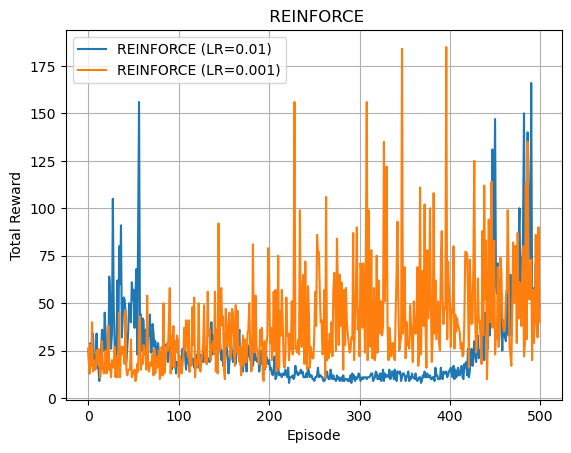

In [5]:
# Define the learning rates 
learning_rates = [0.01, 0.001]
episodes = 500

#plt.figure(figsize=(10, 6))

for lr in learning_rates:
   rewards_history = run_reinforce(lr=lr, episodes=episodes)
    
   # Plot this specific experiment's result on the same chart
   plt.plot(rewards_history, label=f"REINFORCE (LR={lr})")

# Finalize the automated comparison plot
plt.title(" REINFORCE")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.show()

## 🔴 **Reward_to_go**

#### $J(\theta)= E_{\pi_{\theta}}[\sum_{t=0}log\pi_{\theta}(A_{t}|S_{t})G_{t}]$

In [6]:
# --------------------------------------------------------------------------------------------------
# Define the Reward-to-Go Training Function
# --------------------------------------------------------------------------------------------------
def run_reward_to_go(lr, episodes, env_name="CartPole-v1", gamma=0.99, seed=2):
    """
    Runs the Reward-to-Go algorithm with given learning rate and episodes.
    Returns a list of total rewards per episode.
    """
    print(f"\n--- Starting Reward-to-Go Experiment with LR={lr} for {episodes} Episodes ---")
    
    # Create environment
    env = gym.make(env_name, render_mode='rgb_array')
    config = ENV_CONFIG[env_name]

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env.reset(seed=seed)
    env.action_space.seed(seed)
    
    # Create video folder 
    video_folder = f"./{config['video_folder']}_rtg_lr_{lr}"
    
    # Record video every 20 or 100 episodes to speed up execution
    env = RecordVideo(
        env,
        video_folder=video_folder,
        episode_trigger=lambda episode_id: episode_id % config['video_every']  == 0,
        name_prefix=config['video_folder']
    )
    
    # Initialize network and optimizer
    policy = PolicyNet(env.observation_space.shape[0], env.action_space.n, env_name)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    history_rewards_rtg = []
    
    # Main training loop
    for episode in range(episodes):
        state, info = env.reset()

       #---------------------------------------------------------------------------------------------------------------
       # Buffer  (Trajectory) Box: Storage for interaction data
       #---------------------------------------------------------------------------------------------------------------    
        saved_log_probs = []
        rewards = []
        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state)
            action_logits = policy(state_tensor)
            
            m = Categorical(logits=action_logits)
            action = m.sample()
            
            saved_log_probs.append(m.log_prob(action))
            state, reward, terminated, truncated, info = env.step(action.item())
            rewards.append(reward)
            
            done = terminated or truncated
            
       #--------------------------------------------------------------------------------------------------------------
       # Learning Phase: Policy Optimization after episode completion
       #--------------------------------------------------------------------------------------------------------------
        returns = []
        G = 0
    
        for reward in reversed(rewards):
            G = reward + gamma * G
            returns.append(G)
    
        returns.reverse()
        returns = torch.tensor(returns, dtype=torch.float32)
    
        log_probs = torch.stack(saved_log_probs)
        policy_loss = -(log_probs * returns).sum()
        
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()
        
        history_rewards_rtg.append(sum(rewards))
        
        print(f"Episode {episode:03d}  Total Reward: {sum(rewards)}")
            
    env.close()
    return history_rewards_rtg


--- Starting Reward-to-Go Experiment with LR=0.01 for 500 Episodes ---
Episode 000  Total Reward: 26.0
Episode 001  Total Reward: 13.0
Episode 002  Total Reward: 29.0
Episode 003  Total Reward: 28.0
Episode 004  Total Reward: 24.0
Episode 005  Total Reward: 39.0
Episode 006  Total Reward: 16.0
Episode 007  Total Reward: 18.0
Episode 008  Total Reward: 32.0
Episode 009  Total Reward: 15.0
Episode 010  Total Reward: 15.0
Episode 011  Total Reward: 20.0
Episode 012  Total Reward: 15.0
Episode 013  Total Reward: 35.0
Episode 014  Total Reward: 52.0
Episode 015  Total Reward: 26.0
Episode 016  Total Reward: 21.0
Episode 017  Total Reward: 54.0
Episode 018  Total Reward: 33.0
Episode 019  Total Reward: 26.0
Episode 020  Total Reward: 16.0
Episode 021  Total Reward: 36.0
Episode 022  Total Reward: 37.0
Episode 023  Total Reward: 76.0
Episode 024  Total Reward: 53.0
Episode 025  Total Reward: 72.0
Episode 026  Total Reward: 84.0
Episode 027  Total Reward: 12.0
Episode 028  Total Reward: 11.0


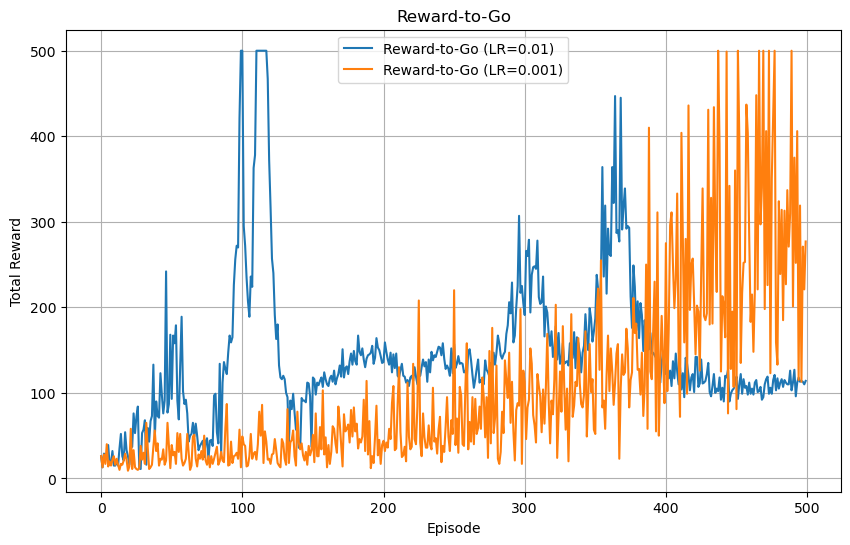

In [7]:
# Define the learning rates 
learning_rates = [0.01, 0.001]
episodes = 500

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    rewards_history_rtg = run_reward_to_go(lr=lr, episodes=episodes)
    
    # Plot this specific experiment's result on the same chart
    plt.plot(rewards_history_rtg, label=f"Reward-to-Go (LR={lr})")

# Finalize the automated comparison plot
plt.title("Reward-to-Go")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.show()

## 🔴 **Baseline**

#### $J(\theta)= E_{\pi_{\theta}}[\sum_{t=0}log\pi_{\theta}(A_{t}|S_{t})(G_{t}-b)]$

In [8]:
# --------------------------------------------------------------------------------------------------
# Define the Baseline Training Function
# --------------------------------------------------------------------------------------------------
def run_baseline(lr, episodes, env_name="CartPole-v1", gamma=0.99, seed=2):
    """
    Runs the REINFORCE algorithm with Baseline (Mean Subtraction) 
    with a given learning rate and episodes.
    Returns a list of total rewards per episode.
    """
    print(f"\n--- Starting Baseline Experiment with LR={lr} for {episodes} Episodes ---")
    
    # Create environment
    env = gym.make(env_name, render_mode='rgb_array')
    config = ENV_CONFIG[env_name]

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env.reset(seed=seed)
    env.action_space.seed(seed)
    
    # Create video folder 
    video_folder = f"./{config['video_folder']}_baseline_lr_{lr}"
    
    # Record video every 20 or 100 episodes to speed up execution
    env = RecordVideo(
        env,
        video_folder=video_folder,
        episode_trigger=lambda episode_id: episode_id % config['video_every'] == 0,
        name_prefix=config['video_folder']
    )
    
    # Initialize network and optimizer
    policy = PolicyNet(env.observation_space.shape[0], env.action_space.n, env_name)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    history_rewards_baseline = []
    
    # Main training loop
    for episode in range(episodes):
        state, info = env.reset()

       #---------------------------------------------------------------------------------------------------------------
       # Buffer  (Trajectory) Box: Storage for interaction data
       #---------------------------------------------------------------------------------------------------------------    
        saved_log_probs = []
        rewards = []
        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state)
            action_logits = policy(state_tensor)
            
            m = Categorical(logits=action_logits)
            action = m.sample()
            
            saved_log_probs.append(m.log_prob(action))
            state, reward, terminated, truncated, info = env.step(action.item())
            rewards.append(reward)
            
            done = terminated or truncated
            
       #--------------------------------------------------------------------------------------------------------------
       # Learning Phase: Policy Optimization with Baseline
       #--------------------------------------------------------------------------------------------------------------
        returns = []
        G = 0
    
        for reward in reversed(rewards):
            G = reward + gamma * G
            returns.append(G)
    
        returns.reverse()
        returns = torch.tensor(returns, dtype=torch.float32)

        # Calculate Advantage using the mean of current episode as baseline
        advantages = returns - returns.mean()
    
        log_probs = torch.stack(saved_log_probs)
        policy_loss = -(log_probs * advantages).sum()
        
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()
        
        history_rewards_baseline.append(sum(rewards))
        
        print(f"Episode {episode:03d}: Total Reward: {sum(rewards):.2f}")
            
    env.close()
    return history_rewards_baseline


--- Starting Baseline Experiment with LR=0.01 for 500 Episodes ---
Episode 000: Total Reward: 26.00
Episode 001: Total Reward: 20.00
Episode 002: Total Reward: 12.00
Episode 003: Total Reward: 13.00
Episode 004: Total Reward: 11.00
Episode 005: Total Reward: 18.00
Episode 006: Total Reward: 18.00
Episode 007: Total Reward: 34.00
Episode 008: Total Reward: 23.00
Episode 009: Total Reward: 15.00
Episode 010: Total Reward: 17.00
Episode 011: Total Reward: 38.00
Episode 012: Total Reward: 17.00
Episode 013: Total Reward: 13.00
Episode 014: Total Reward: 15.00
Episode 015: Total Reward: 63.00
Episode 016: Total Reward: 35.00
Episode 017: Total Reward: 66.00
Episode 018: Total Reward: 30.00
Episode 019: Total Reward: 30.00
Episode 020: Total Reward: 11.00
Episode 021: Total Reward: 59.00
Episode 022: Total Reward: 72.00
Episode 023: Total Reward: 81.00
Episode 024: Total Reward: 85.00
Episode 025: Total Reward: 71.00
Episode 026: Total Reward: 43.00
Episode 027: Total Reward: 69.00
Episode 

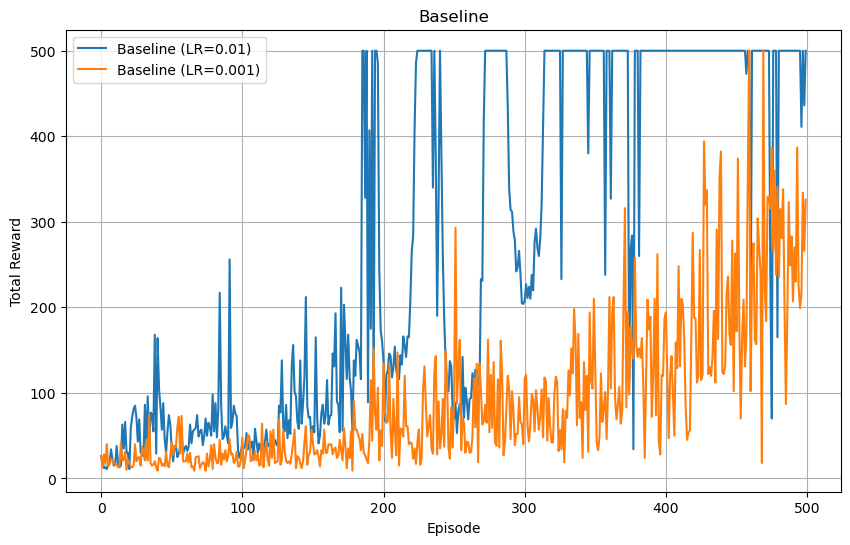

In [9]:
# Define the learning rates 
learning_rates = [0.01, 0.001]
episodes = 500

plt.figure(figsize=(10, 6))

for lr in learning_rates:
    rewards_history_baseline = run_baseline(lr=lr, episodes=episodes)
    
    # Plot this specific experiment's result on the same chart
    plt.plot(rewards_history_baseline, label=f"Baseline (LR={lr})")

# Finalize the automated comparison plot
plt.title("Baseline")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.savefig("baseline_rewards.png", dpi=300, bbox_inches='tight') 
plt.show()

### 🟠 **Comparison of REINFORCE, Reward-to-Go, and Baseline**


=== Executing Experiments for Learning Rate: 0.01 ===

--- Starting REINFORCE Experiment with LR=0.01 for 500 Episodes ---
Episode 000: Total Reward (R_tau): 26.0
Episode 001: Total Reward (R_tau): 13.0
Episode 002: Total Reward (R_tau): 29.0
Episode 003: Total Reward (R_tau): 28.0
Episode 004: Total Reward (R_tau): 20.0
Episode 005: Total Reward (R_tau): 34.0
Episode 006: Total Reward (R_tau): 21.0
Episode 007: Total Reward (R_tau): 15.0
Episode 008: Total Reward (R_tau): 18.0
Episode 009: Total Reward (R_tau): 34.0
Episode 010: Total Reward (R_tau): 16.0
Episode 011: Total Reward (R_tau): 16.0
Episode 012: Total Reward (R_tau): 9.0
Episode 013: Total Reward (R_tau): 17.0
Episode 014: Total Reward (R_tau): 25.0
Episode 015: Total Reward (R_tau): 36.0
Episode 016: Total Reward (R_tau): 34.0
Episode 017: Total Reward (R_tau): 25.0
Episode 018: Total Reward (R_tau): 45.0
Episode 019: Total Reward (R_tau): 34.0
Episode 020: Total Reward (R_tau): 17.0
Episode 021: Total Reward (R_tau): 17

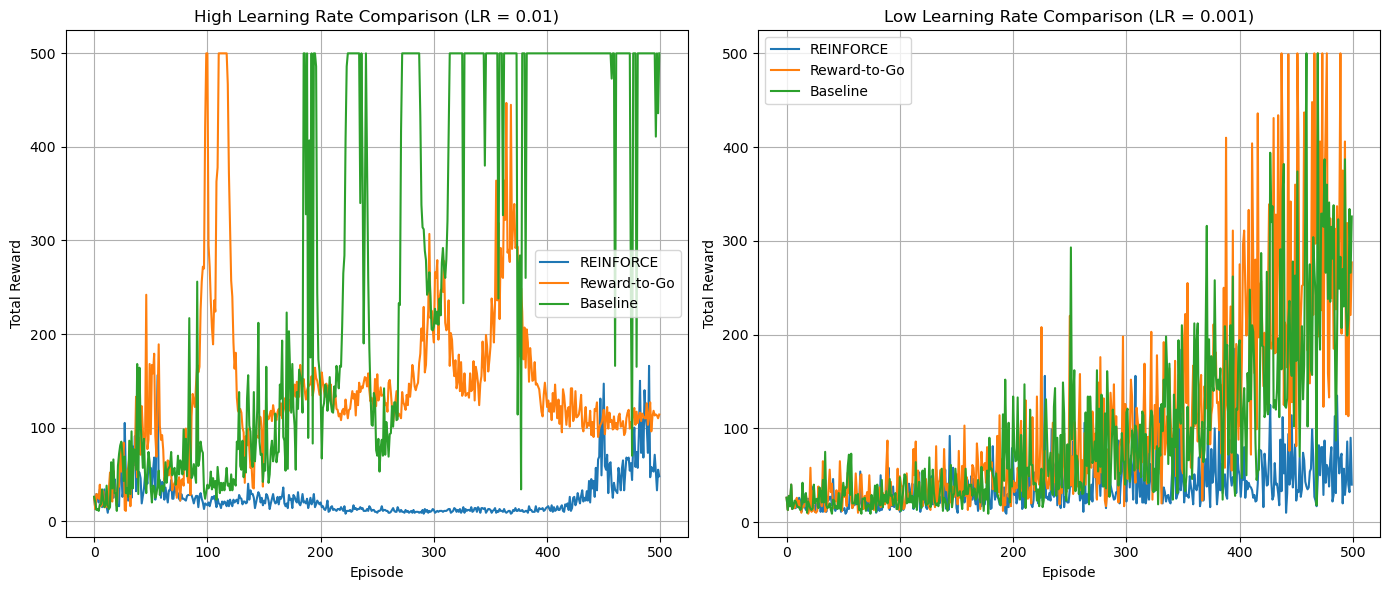

In [11]:
episodes_count = 500

# Containers for results
results = { 
    0.01: {},
    0.001: {}
}

# Run all experiments
for current_lr in [0.01, 0.001]:
    print(f"\n=== Executing Experiments for Learning Rate: {current_lr} ===")
    results[current_lr]["REINFORCE"] = run_reinforce(current_lr, episodes_count)
    results[current_lr]["Reward-to-Go"] = run_reward_to_go(current_lr, episodes_count)
    results[current_lr]["Baseline"] = run_baseline(current_lr, episodes_count)

# --------------------------------------------------------------------------------------------------
# Plotting the Grand Comparison
# --------------------------------------------------------------------------------------------------
plt.figure(figsize=(14, 6))

#Plot 1: High Learning Rate (0.01)
plt.subplot(1, 2, 1)
for method, data in results[0.01].items():
    plt.plot(data, label=method)
plt.title("High Learning Rate Comparison (LR = 0.01)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()

# Plot 2: Low Learning Rate (0.001)
plt.subplot(1, 2, 2)
for method, data in results[0.001].items():
    plt.plot(data, label=method)
plt.title("Low Learning Rate Comparison (LR = 0.001)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.savefig("comparison.png", dpi=300, bbox_inches="tight")
plt.show()

###  🟠  **Lunar Lander**


--- Starting Baseline Experiment with LR=0.001 for 3000 Episodes ---
Episode 000: Total Reward: -199.69
Episode 001: Total Reward: -210.86
Episode 002: Total Reward: -178.96
Episode 003: Total Reward: -141.97
Episode 004: Total Reward: -196.78
Episode 005: Total Reward: -176.98
Episode 006: Total Reward: -138.72
Episode 007: Total Reward: -92.53
Episode 008: Total Reward: -118.92
Episode 009: Total Reward: -98.54
Episode 010: Total Reward: -215.55
Episode 011: Total Reward: -93.05
Episode 012: Total Reward: -161.76
Episode 013: Total Reward: -67.91
Episode 014: Total Reward: -447.66
Episode 015: Total Reward: -317.73
Episode 016: Total Reward: -115.97
Episode 017: Total Reward: -105.99
Episode 018: Total Reward: -101.85
Episode 019: Total Reward: -97.99
Episode 020: Total Reward: -194.58
Episode 021: Total Reward: -353.68
Episode 022: Total Reward: -104.63
Episode 023: Total Reward: -144.83
Episode 024: Total Reward: -102.84
Episode 025: Total Reward: -355.02
Episode 026: Total Reward

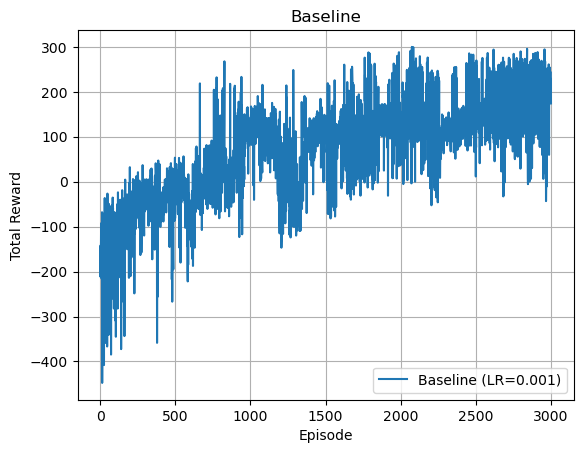

In [5]:
env_name = "LunarLander-v3"
learning_rate = 0.001
episodes = 3000

rewards_history_baseline = run_baseline(lr=learning_rate, episodes=episodes, env_name=env_name)
    
plt.plot(rewards_history_baseline, label=f"Baseline (LR={learning_rate})")

plt.title("Baseline")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.legend()
plt.grid(True)
plt.savefig(f"baseline_rewards_{env_name}.png", dpi=300, bbox_inches='tight') 
plt.show()